<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Google_Trends_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytrends pandas matplotlib statsmodels

In [3]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

Step 1: Connect to Google Trends


In [4]:
pytrends = TrendReq(hl='en-US', tz=360)

Step 2: Choose your keyword

In [6]:
keyword = "Christmas"
pytrends.build_payload([keyword], cat=0, timeframe='today 5-y', geo='', gprop='')

Step 3: Get data

In [8]:
data = pytrends.interest_over_time()

if 'isPartial' in data.columns:
    data = data.drop(columns=['isPartial'])

/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


Step 4: Plot raw data

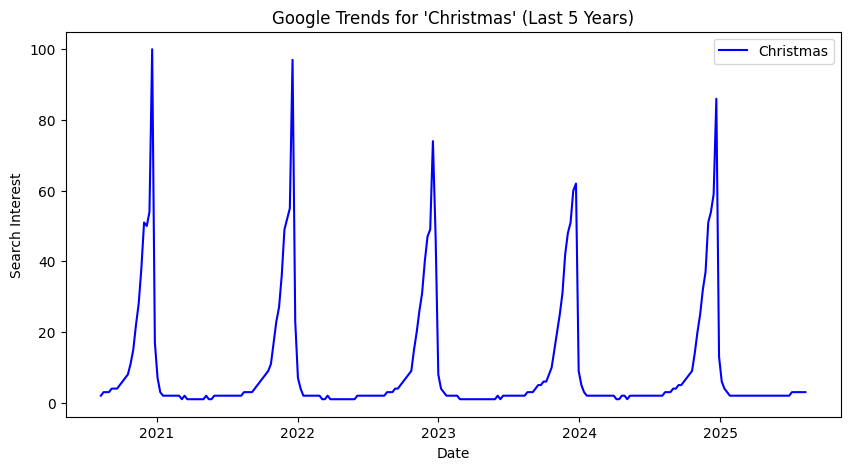

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data[keyword], label=keyword, color='blue')
plt.title(f"Google Trends for '{keyword}' (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()
plt.show()

Step 5: Seasonal Decomposition

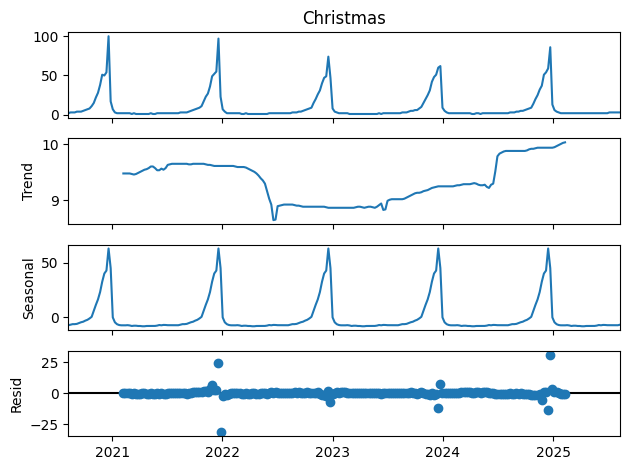

In [10]:
decomposition = seasonal_decompose(data[keyword], model='additive', period=52)
decomposition.plot()
plt.show()